/Users/utsabchakraborty/Documents/Edureka_May2026/LangGraph/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


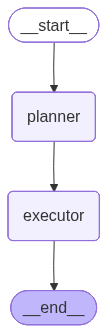


Planning tasks...


Executing plan...


PLAN

### Execution Plan for Launching an AI-Powered eCommerce Chatbot

#### 1. **Market Research & Analysis**
   - **Objective:** Identify the target audience and market needs.
   - **Actions:**
     - Survey existing customers and potential users for their needs and preferences.
     - Analyze competitor chatbots, identifying features and user experiences.
     - Gather insights on industry trends related to AI and eCommerce.
   - **Timeline:** 2 weeks
   - **Responsible:** Marketing Research Team

#### 2. **Define Chatbot Objectives**
   - **Objective:** Establish the purpose and capabilities of the chatbot.
   - **Actions:**
     - Decide on primary functions (e.g., customer service, product recommendations, order tracking).
     - Determine performance metrics (response time, customer satisfaction, conversion rate).
   - **Timeline:** 1 week
   - **Responsible:** Product Development Team

#### 3. **Select Technology Stack**
   - **Objective

In [1]:
"""
=============================================================
FILE 30 — PLANNER EXECUTOR AGENT
=============================================================

CONCEPTS TAUGHT
----------------
1. Planner-Executor Pattern
2. Task Decomposition
3. Planning Agents
4. Execution Agents
5. Multi-Step Task Execution
6. Agent Coordination
7. Structured Planning
8. Sequential Execution
9. Workflow Orchestration
10. Enterprise Agent Systems

CORE IDEA
-----------
Separate:
- planning
from
- execution

FLOW
-----
Planner
   ↓
Creates Plan
   ↓
Executor Executes Tasks
   ↓
Final Output

REAL WORLD USE CASES
---------------------
- Travel planning
- Autonomous coding agents
- AI project managers
- Research systems
"""

# ============================================================
# STEP 1 — IMPORTS
# ============================================================

import os

from dotenv import load_dotenv

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display

# ============================================================
# STEP 2 — LOAD ENV VARIABLES
# ============================================================

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# ============================================================
# STEP 3 — INITIALIZE LLM
# ============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

# ============================================================
# STEP 4 — DEFINE STATE
# ============================================================

class State(TypedDict):
    objective: str
    plan: str
    execution_result: str

# ============================================================
# STEP 5 — PLANNER NODE
# ============================================================

def planner(state: State):

    """
    Creates execution plan.
    """

    print("\nPlanning tasks...\n")

    response = llm.invoke(
        f"""
        Create a detailed execution plan for:

        {state['objective']}
        """
    )

    return {
        "plan": response.content
    }

# ============================================================
# STEP 6 — EXECUTOR NODE
# ============================================================

def executor(state: State):

    """
    Executes the generated plan.
    """

    print("\nExecuting plan...\n")

    response = llm.invoke(
        f"""
        Execute the following plan step-by-step.

        PLAN:
        {state['plan']}
        """
    )

    return {
        "execution_result": response.content
    }

# ============================================================
# STEP 7 — BUILD GRAPH
# ============================================================

builder = StateGraph(State)

builder.add_node("planner", planner)

builder.add_node("executor", executor)

# ============================================================
# STEP 8 — DEFINE EDGES
# ============================================================

builder.add_edge(
    START,
    "planner"
)

builder.add_edge(
    "planner",
    "executor"
)

builder.add_edge(
    "executor",
    END
)

# ============================================================
# STEP 9 — COMPILE GRAPH
# ============================================================

graph = builder.compile()

# ============================================================
# STEP 10 — VISUALIZE GRAPH
# ============================================================

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

# ============================================================
# STEP 11 — RUN WORKFLOW
# ============================================================

result = graph.invoke(
    {
        "objective":
        """
        Launch an AI-powered eCommerce chatbot
        """
    }
)

# ============================================================
# STEP 12 — PRINT RESULTS
# ============================================================

print("\nPLAN\n")
print("=" * 60)
print(result["plan"])

print("\nEXECUTION RESULT\n")
print("=" * 60)
print(result["execution_result"])